In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
import statsmodels.api as sm

In [2]:
data_path="/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Data"
figures_path="/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Figures"
tables_path="/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Table"

In [3]:
underlying_ticker = "PLTR"

# PLTR-related LETF candidates
letf_candidates = ["PLTU", "PTIR", "PLTG", "PLTA"]

start_date = "2010-01-01"
end_date = None  # None means latest available

In [4]:
def download_prices(tickers, start="2024-01-01", end=None):
    """
    Download adjusted close prices using yfinance.
    Returns a DataFrame with tickers as columns.
    """
    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )
    
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = tickers
    
    prices = prices.dropna(how="all")
    return prices


tickers = [underlying_ticker] + letf_candidates
prices = download_prices(tickers, start=start_date, end=end_date)

prices.tail()

Ticker,PLTA,PLTG,PLTR,PLTU,PTIR
Date,,,,,
2026-06-02,17.16,15.932,152.169998,44.759998,16.530001
2026-06-03,14.95,13.810,142.199997,38.930000,14.380000
2026-06-04,14.83,13.710,141.699997,38.619999,14.250000
2026-06-05,13.53,12.480,135.529999,35.259998,13.050000
2026-06-08,13.69,12.640,136.470001,35.669998,13.170000


In [5]:
# Save raw price data
prices.to_csv("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Data/pltr_related_raw_prices.csv")

In [6]:
def summarize_data_availability(prices):
    rows = []
    
    for ticker in prices.columns:
        s = prices[ticker].dropna()
        
        if len(s) == 0:
            rows.append({
                "Ticker": ticker,
                "Start Date": None,
                "End Date": None,
                "Observations": 0,
                "Missing Values": prices[ticker].isna().sum()
            })
        else:
            rows.append({
                "Ticker": ticker,
                "Start Date": s.index.min().date(),
                "End Date": s.index.max().date(),
                "Observations": len(s),
                "Missing Values": prices[ticker].isna().sum()
            })
    
    return pd.DataFrame(rows)


availability = summarize_data_availability(prices)
availability

,Ticker,Start Date,End Date,Observations,Missing Values
0,PLTA,2025-09-10,2026-06-08,187,1241
1,PLTG,2025-04-25,2026-06-08,281,1147
2,PLTR,2020-09-30,2026-06-08,1428,0
3,PLTU,2024-12-11,2026-06-08,372,1056
4,PTIR,2024-09-04,2026-06-08,441,987


In [7]:
selected_letf = "PTIR"
selected_underlying = "PLTR"

data = prices[[selected_underlying, selected_letf]].dropna().copy()
data.columns = ["Underlying", "LETF"]

print(data.index.min())
print(data.index.max())
print(len(data))
print(data.tail())

2024-09-04 00:00:00
2026-06-08 00:00:00
441
            Underlying       LETF
Date                             
2026-06-02  152.169998  16.530001
2026-06-03  142.199997  14.380000
2026-06-04  141.699997  14.250000
2026-06-05  135.529999  13.050000
2026-06-08  136.470001  13.170000


In [8]:
# Save cleaned data for selected underlying and LETF
data.to_csv("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Data/PTIR_clean_price_data.csv")

In [9]:
# Daily Returns
returns = data.pct_change().dropna()

returns.columns = ["Underlying_Return", "LETF_Return"]

returns.tail()

,Underlying_Return,LETF_Return
Date,,
2026-06-02,-0.052786,-0.106003
2026-06-03,-0.065519,-0.130067
2026-06-04,-0.003516,-0.009040
2026-06-05,-0.043543,-0.084211
2026-06-08,0.006936,0.009195


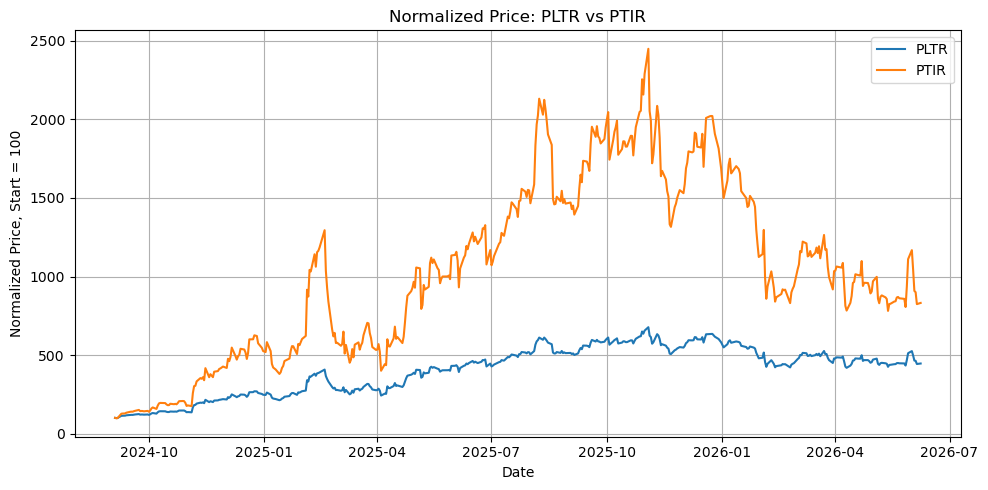

In [10]:
#Normalized Price Comparison: PLTR vs PLTR LETF
normalized = data / data.iloc[0] * 100

plt.figure(figsize=(10, 5))
plt.plot(normalized.index, normalized["Underlying"], label=selected_underlying)
plt.plot(normalized.index, normalized["LETF"], label=selected_letf)
plt.title(f"Normalized Price: {selected_underlying} vs {selected_letf}")
plt.xlabel("Date")
plt.ylabel("Normalized Price, Start = 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Figures/EDA1_PTIR_normalized_price.png", dpi=300)
plt.show()


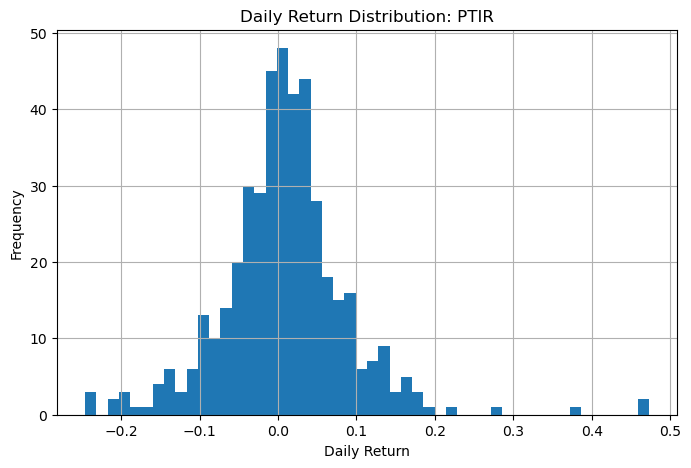

In [11]:
#Daily Return Distribution
plt.figure(figsize=(8, 5))
plt.hist(returns["LETF_Return"], bins=50)
plt.title(f"Daily Return Distribution: {selected_letf}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Figures/EDA2_PTIR_return_distribution.png", dpi=300)
plt.show()

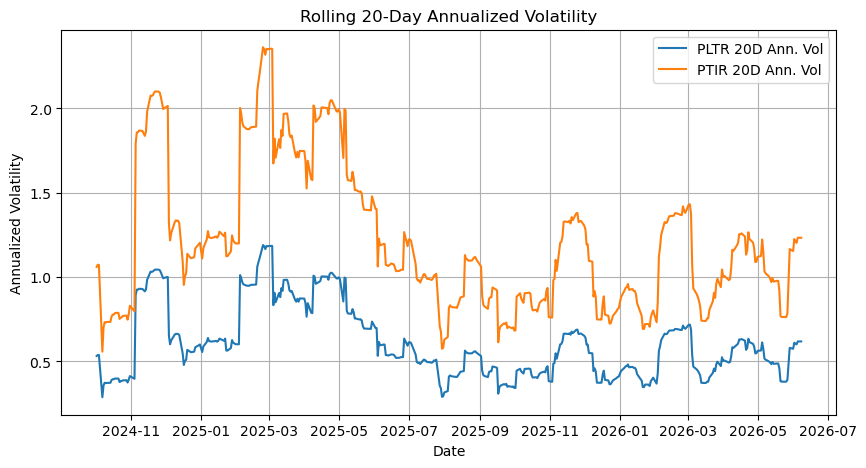

In [12]:
#Volatility

rolling_window = 20

rolling_vol = returns.rolling(rolling_window).std() * np.sqrt(252)

plt.figure(figsize=(10, 5))
plt.plot(rolling_vol.index, rolling_vol["Underlying_Return"], label=f"{selected_underlying} 20D Ann. Vol")
plt.plot(rolling_vol.index, rolling_vol["LETF_Return"], label=f"{selected_letf} 20D Ann. Vol")
plt.title(f"Rolling {rolling_window}-Day Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.savefig("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Figures/EDA3_PTIR_rolling_volatility.png", dpi=300)
plt.show()

In [13]:
#EDA summary metrics
def max_drawdown(price_or_nav):
    """
    Compute max drawdown from a price or NAV series.
    """
    running_max = price_or_nav.cummax()
    drawdown = price_or_nav / running_max - 1
    return drawdown.min()


def calculate_return_metrics(price_series):
    """
    Calculate basic return metrics for a price series.
    """
    ret = price_series.pct_change().dropna()
    
    total_return = price_series.iloc[-1] / price_series.iloc[0] - 1
    daily_vol = ret.std()
    ann_vol = daily_vol * np.sqrt(252)
    avg_daily_return = ret.mean()
    ann_return = (1 + avg_daily_return) ** 252 - 1
    
    mdd = max_drawdown(price_series)
    worst_1d = ret.min()
    best_1d = ret.max()
    
    return {
        "Start Date": price_series.index.min().date(),
        "End Date": price_series.index.max().date(),
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Daily Vol": daily_vol,
        "Annualized Vol": ann_vol,
        "Max Drawdown": mdd,
        "Worst 1D Return": worst_1d,
        "Best 1D Return": best_1d
    }


metrics_underlying = calculate_return_metrics(data["Underlying"])
metrics_letf = calculate_return_metrics(data["LETF"])

eda_summary = pd.DataFrame(
    [metrics_underlying, metrics_letf],
    index=[selected_underlying, selected_letf]
)

eda_summary

,Start Date,End Date,Total Return,Annualized Return,Daily Vol,Annualized Vol,Max Drawdown,Worst 1D Return,Best 1D Return
PLTR,2024-09-04,2026-06-08,3.461262,1.888253,0.040801,0.647691,-0.406115,-0.120465,0.239909
PTIR,2024-09-04,2026-06-08,7.318438,6.520899,0.081471,1.293317,-0.691020,-0.245603,0.472427


In [14]:
eda_summary_formatted = eda_summary.copy()

percent_cols = [
    "Total Return",
    "Annualized Return",
    "Daily Vol",
    "Annualized Vol",
    "Max Drawdown",
    "Worst 1D Return",
    "Best 1D Return"
]

for col in percent_cols:
    eda_summary_formatted[col] = eda_summary_formatted[col].apply(lambda x: f"{x:.2%}")

eda_summary_formatted

,Start Date,End Date,Total Return,Annualized Return,Daily Vol,Annualized Vol,Max Drawdown,Worst 1D Return,Best 1D Return
PLTR,2024-09-04,2026-06-08,346.13%,188.83%,4.08%,64.77%,-40.61%,-12.05%,23.99%
PTIR,2024-09-04,2026-06-08,731.84%,652.09%,8.15%,129.33%,-69.10%,-24.56%,47.24%


In [15]:
eda_summary_formatted.to_csv(
    f"{tables_path}/EDA1_{selected_letf}_summary.csv",
    index=False
)

In [16]:
letf_ret = returns["LETF_Return"]
short_letf_ret = -letf_ret
short_letf_nav = (1 + short_letf_ret).cumprod()
short_letf_nav.head()

Date
2024-09-05    1.024150
2024-09-06    1.015155
2024-09-09    0.728120
2024-09-10    0.720499
2024-09-11    0.719595
Name: LETF_Return, dtype: float64

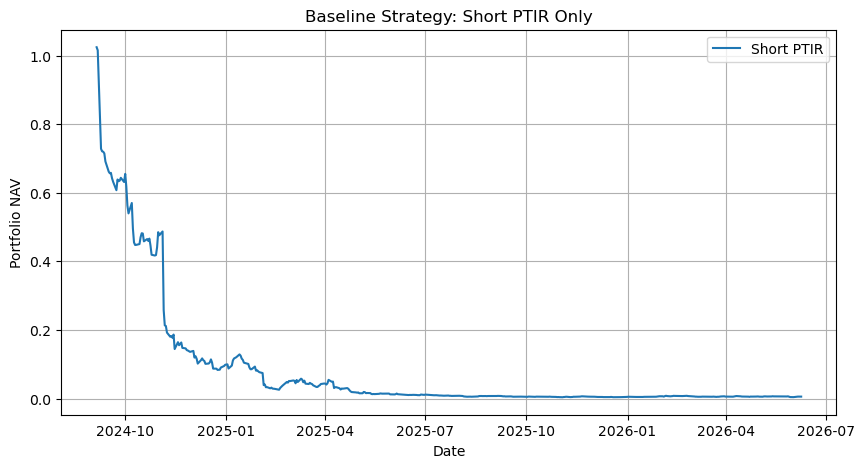

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(short_letf_nav.index, short_letf_nav, label=f"Short {selected_letf}")
plt.title(f"Baseline Strategy: Short {selected_letf} Only")
plt.xlabel("Date")
plt.ylabel("Portfolio NAV")
plt.legend()
plt.grid(True)
plt.savefig("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Figures/EDA4_PTIR_short_only_nav.png", dpi=300)
plt.show()

In [18]:
def calculate_strategy_metrics(strategy_returns):
    """
    Calculate strategy performance metrics from daily returns.
    """
    nav = (1 + strategy_returns).cumprod()
    
    total_return = nav.iloc[-1] - 1
    avg_daily_return = strategy_returns.mean()
    ann_return = (1 + avg_daily_return) ** 252 - 1
    daily_vol = strategy_returns.std()
    ann_vol = daily_vol * np.sqrt(252)
    
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    
    mdd = max_drawdown(nav)
    worst_1d_loss = strategy_returns.min()
    best_1d_gain = strategy_returns.max()
    
    return {
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Worst 1D Loss": worst_1d_loss,
        "Best 1D Gain": best_1d_gain
    }


short_only_metrics = calculate_strategy_metrics(short_letf_ret)

short_only_metrics_df = pd.DataFrame([short_only_metrics], index=["Short LETF Only"])
short_only_metrics_df

,Total Return,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Worst 1D Loss,Best 1D Gain
Short LETF Only,-0.994247,-0.869185,1.293317,-0.672059,-0.996103,-0.472427,0.245603


In [19]:
short_only_formatted = short_only_metrics_df.copy()

for col in ["Total Return", "Annualized Return", "Annualized Vol", "Max Drawdown", "Worst 1D Loss", "Best 1D Gain"]:
    short_only_formatted[col] = short_only_formatted[col].apply(lambda x: f"{x:.2%}")

short_only_formatted["Sharpe"] = short_only_formatted["Sharpe"].apply(lambda x: f"{x:.2f}")

short_only_formatted

,Total Return,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Worst 1D Loss,Best 1D Gain
Short LETF Only,-99.42%,-86.92%,129.33%,-0.67,-99.61%,-47.24%,24.56%


In [20]:
# Save short-only baseline summary
short_only_formatted.to_csv("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Table/EDA2_PTIR_short_only_summary.csv")

In [21]:
risk_days = pd.DataFrame({
    "Underlying Return": returns["Underlying_Return"],
    "LETF Return": returns["LETF_Return"],
    "Short LETF Return": short_letf_ret
})

worst_short_days = risk_days.sort_values("LETF Return", ascending=False).head(10)

worst_short_days_formatted = worst_short_days.copy()
for col in worst_short_days_formatted.columns:
    worst_short_days_formatted[col] = worst_short_days_formatted[col].apply(lambda x: f"{x:.2%}")

worst_short_days_formatted

,Underlying Return,LETF Return,Short LETF Return
Date,,,
2025-02-04,23.99%,47.24%,-47.24%
2024-11-05,23.47%,47.01%,-47.01%
2025-04-09,19.00%,37.85%,-37.85%
2024-09-09,14.08%,28.27%,-28.27%
2024-11-15,11.14%,22.63%,-22.63%
2025-02-06,9.79%,19.50%,-19.50%
2026-05-29,9.21%,18.46%,-18.46%
2025-11-10,8.81%,17.41%,-17.41%
2024-11-06,8.61%,17.34%,-17.34%


In [22]:
# Save worst short-loss days
worst_short_days_formatted.to_csv("/Users/deeeer/Downloads/LETF Hedging Project/PLTR_LETF_Analysis/Table/EDA3_PTIR_worst_short_days.csv")

In [23]:
# ============================================================
# EDA Extension 1: Tracking / Beta Analysis
# Purpose:
#   Check how closely PTIR tracks PLTR on a daily return basis.
#   If PTIR targets 2x daily exposure to PLTR, the regression beta
#   should be close to 2.
# ============================================================

# Prepare regression data
tracking_df = pd.DataFrame({
    "PLTR_Return": returns["Underlying_Return"],
    "PTIR_Return": returns["LETF_Return"]
}).dropna()

# X = PLTR daily returns
# Y = PTIR daily returns
x = tracking_df["PLTR_Return"].values
y = tracking_df["PTIR_Return"].values

# Run simple linear regression:
# PTIR_Return = alpha + beta * PLTR_Return
beta, alpha = np.polyfit(x, y, 1)

# Fitted values
tracking_df["Fitted_PTIR_Return"] = alpha + beta * tracking_df["PLTR_Return"]

# Calculate R-squared
ss_res = np.sum((tracking_df["PTIR_Return"] - tracking_df["Fitted_PTIR_Return"]) ** 2)
ss_tot = np.sum((tracking_df["PTIR_Return"] - tracking_df["PTIR_Return"].mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

# Tracking error:
# Difference between actual PTIR return and theoretical 2x PLTR return
tracking_df["Theoretical_2x_Return"] = 2 * tracking_df["PLTR_Return"]
tracking_df["Tracking_Error"] = tracking_df["PTIR_Return"] - tracking_df["Theoretical_2x_Return"]

# Summary table
tracking_summary = pd.DataFrame({
    "Metric": [
        "Regression Alpha",
        "Regression Beta / Realized Leverage",
        "Target Leverage",
        "Beta Difference from Target",
        "R-squared",
        "Mean Daily Tracking Error",
        "Tracking Error Volatility"
    ],
    "Value": [
        alpha,
        beta,
        2.0,
        beta - 2.0,
        r_squared,
        tracking_df["Tracking_Error"].mean(),
        tracking_df["Tracking_Error"].std()
    ]
})

tracking_summary

,Metric,Value
0,Regression Alpha,-0.000382
1,Regression Beta / Realized Leverage,1.996498
2,Target Leverage,2.000000
3,Beta Difference from Target,-0.003502
4,R-squared,0.999684
5,Mean Daily Tracking Error,-0.000397
6,Tracking Error Volatility,0.001455


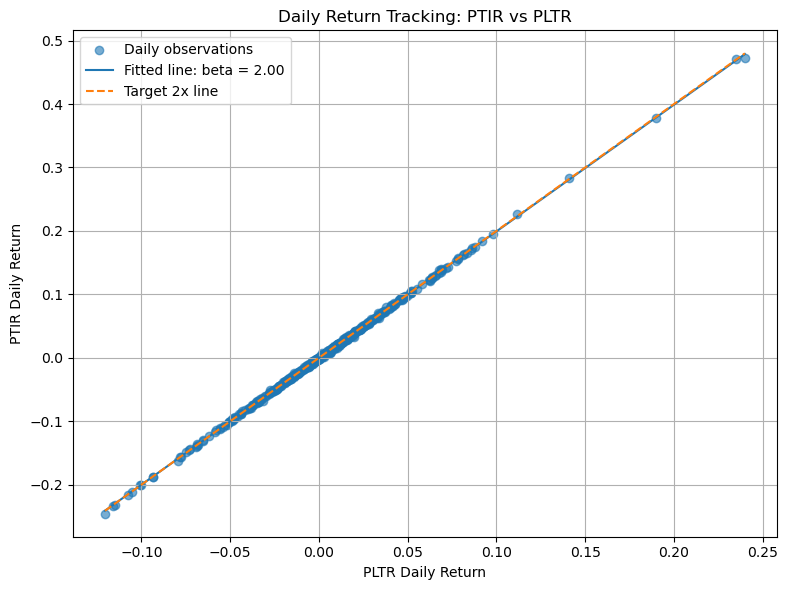

In [24]:
# ============================================================
# Tracking scatter plot
# X-axis: PLTR daily return
# Y-axis: PTIR daily return
# ============================================================

plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(
    tracking_df["PLTR_Return"],
    tracking_df["PTIR_Return"],
    alpha=0.6,
    label="Daily observations"
)

# Regression fitted line
x_line = np.linspace(tracking_df["PLTR_Return"].min(), tracking_df["PLTR_Return"].max(), 100)
y_fitted = alpha + beta * x_line
plt.plot(
    x_line,
    y_fitted,
    label=f"Fitted line: beta = {beta:.2f}"
)

# Theoretical 2x line
plt.plot(
    x_line,
    2 * x_line,
    linestyle="--",
    label="Target 2x line"
)

plt.title(f"Daily Return Tracking: {selected_letf} vs {selected_underlying}")
plt.xlabel(f"{selected_underlying} Daily Return")
plt.ylabel(f"{selected_letf} Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA5_{selected_letf}_tracking_beta_scatter.png",
    dpi=300
)

plt.show()

In [25]:
# Save tracking analysis output
tracking_summary.to_csv(
    f"{tables_path}/EDA4_{selected_letf}_tracking_beta_summary.csv",
    index=False
)

tracking_df.to_csv(
    f"{data_path}/EDA_{selected_letf}_tracking_analysis_data.csv"
)

In [26]:
# ============================================================
# EDA Extension 2: Drawdown Analysis
# Purpose:
#   Quantify how severe the unhedged short PTIR drawdown is.
# ============================================================

def calculate_drawdown_details(nav_series):
    """
    Calculate drawdown curve and identify the maximum drawdown period.

    Input:
        nav_series: portfolio NAV series

    Output:
        drawdown_df: DataFrame with NAV, running peak, and drawdown
        drawdown_details: dictionary with max drawdown details
    """

    nav = nav_series.dropna().copy()

    # Running historical peak of NAV
    running_peak = nav.cummax()

    # Drawdown = NAV / running peak - 1
    drawdown = nav / running_peak - 1

    # Trough date = date with the most negative drawdown
    trough_date = drawdown.idxmin()
    max_dd = drawdown.loc[trough_date]

    # Peak date = most recent date before trough when NAV was at running peak
    peak_date = nav.loc[:trough_date].idxmax()

    # Recovery date:
    # first date after trough where NAV returns to previous peak
    post_trough_nav = nav.loc[trough_date:]
    recovery_candidates = post_trough_nav[post_trough_nav >= nav.loc[peak_date]]

    if len(recovery_candidates) > 0:
        recovery_date = recovery_candidates.index[0]
        recovered = True
    else:
        recovery_date = None
        recovered = False

    # Drawdown duration
    if recovery_date is not None:
        drawdown_duration_days = (recovery_date - peak_date).days
    else:
        drawdown_duration_days = (nav.index[-1] - peak_date).days

    drawdown_df = pd.DataFrame({
        "NAV": nav,
        "Running Peak": running_peak,
        "Drawdown": drawdown
    })

    drawdown_details = {
        "Max Drawdown": max_dd,
        "Peak Date": peak_date,
        "Trough Date": trough_date,
        "Recovery Date": recovery_date,
        "Recovered": recovered,
        "Drawdown Duration Days": drawdown_duration_days,
        "Peak NAV": nav.loc[peak_date],
        "Trough NAV": nav.loc[trough_date]
    }

    return drawdown_df, drawdown_details


# Calculate drawdown for short PTIR only
short_ptir_drawdown_df, short_ptir_drawdown_details = calculate_drawdown_details(short_letf_nav)

short_ptir_drawdown_details

{'Max Drawdown': -0.9961025761385638,
 'Peak Date': Timestamp('2024-09-05 00:00:00'),
 'Trough Date': Timestamp('2025-11-03 00:00:00'),
 'Recovery Date': None,
 'Recovered': False,
 'Drawdown Duration Days': 641,
 'Peak NAV': 1.0241499647318264,
 'Trough NAV': 0.003991546510234891}

In [27]:
# Format drawdown details for display
drawdown_summary = pd.DataFrame([short_ptir_drawdown_details])

drawdown_summary_formatted = drawdown_summary.copy()

drawdown_summary_formatted["Max Drawdown"] = drawdown_summary_formatted["Max Drawdown"].apply(lambda x: f"{x:.2%}")
drawdown_summary_formatted["Peak NAV"] = drawdown_summary_formatted["Peak NAV"].apply(lambda x: f"{x:.4f}")
drawdown_summary_formatted["Trough NAV"] = drawdown_summary_formatted["Trough NAV"].apply(lambda x: f"{x:.4f}")

drawdown_summary_formatted

,Max Drawdown,Peak Date,Trough Date,Recovery Date,Recovered,Drawdown Duration Days,Peak NAV,Trough NAV
0,-99.61%,2024-09-05,2025-11-03,None,False,641,1.0241,0.0040


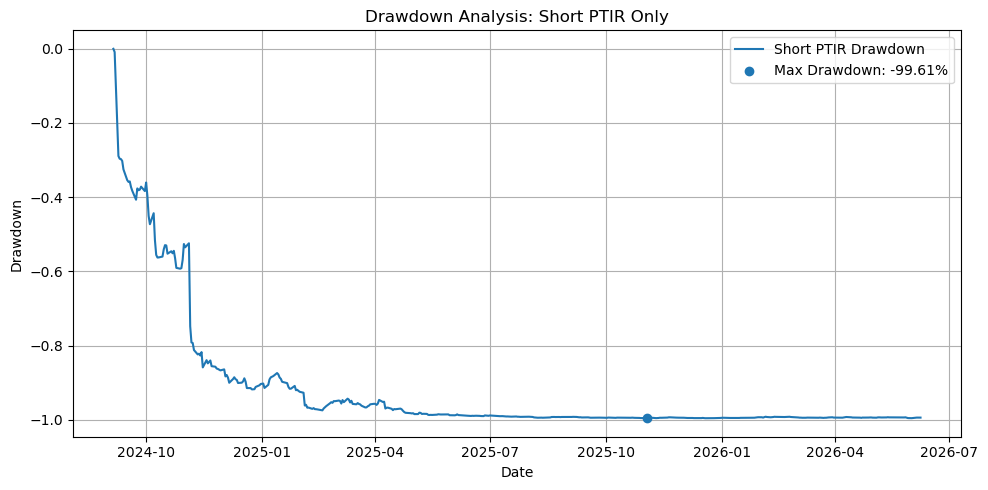

In [28]:
# ============================================================
# Plot drawdown curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    short_ptir_drawdown_df.index,
    short_ptir_drawdown_df["Drawdown"],
    label=f"Short {selected_letf} Drawdown"
)

# Mark trough date
trough_date = short_ptir_drawdown_details["Trough Date"]
max_dd = short_ptir_drawdown_details["Max Drawdown"]

plt.scatter(
    trough_date,
    max_dd,
    zorder=5,
    label=f"Max Drawdown: {max_dd:.2%}"
)

plt.title(f"Drawdown Analysis: Short {selected_letf} Only")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA6_{selected_letf}_short_only_drawdown.png",
    dpi=300
)

plt.show()

In [29]:
# Save drawdown outputs
short_ptir_drawdown_df.to_csv(
    f"{data_path}/EDA_{selected_letf}_short_only_drawdown_series.csv"
)

drawdown_summary_formatted.to_csv(
    f"{tables_path}/EDA5_{selected_letf}_short_only_drawdown_summary.csv",
    index=False
)

In [31]:
# ============================================================
# EDA Extension 3: Setup for Deeper EDA
# Purpose:
#   Add robust path handling, target leverage, and helper functions
#   for realized leverage, decay analysis, and regime analysis.
# ============================================================

# PTIR is a 2x PLTR LETF.
# Change this if you later use a 1.5x, 2x, or 3x LETF.
target_leverage = 2.0

# Clean return dataframe for later analysis
eda_df = pd.DataFrame({
    "Underlying_Price": data["Underlying"],
    "LETF_Price": data["LETF"],
    "Underlying_Return": returns["Underlying_Return"],
    "LETF_Return": returns["LETF_Return"]
}).dropna()

eda_df.head()

,Underlying_Price,LETF_Price,Underlying_Return,LETF_Return
Date,,,,
2024-09-05,30.160000,1.544995,-0.014057,-0.024150
2024-09-06,30.330000,1.558565,0.005637,0.008783
2024-09-09,34.599998,1.999249,0.140785,0.282750
2024-09-10,34.759998,2.020173,0.004624,0.010466
2024-09-11,34.849998,2.022710,0.002589,0.001256


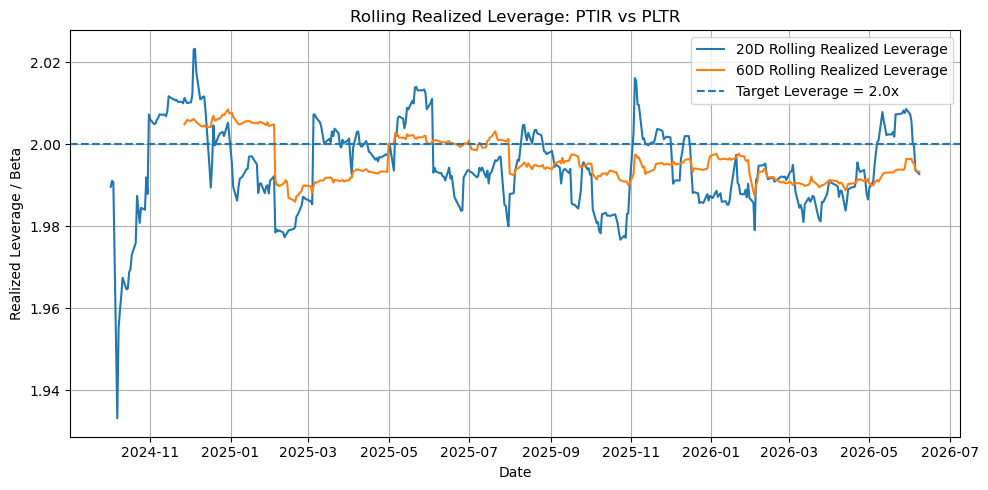

,Metric,Value
0,20D Rolling Beta Mean,1.994196
1,20D Rolling Beta Median,1.993565
2,20D Rolling Beta Min,1.933124
3,20D Rolling Beta Max,2.023315
4,60D Rolling Beta Mean,1.995710
5,60D Rolling Beta Median,1.994344
6,60D Rolling Beta Min,1.985960
7,60D Rolling Beta Max,2.008534


In [33]:
# ============================================================
# EDA Extension 4: Rolling Realized Leverage
# Purpose:
#   Estimate time-varying realized leverage:
#       LETF_Return = alpha + beta * Underlying_Return
#   This checks whether PTIR consistently behaves like a 2x PLTR product.
# ============================================================

def rolling_beta(y, x, window=20):
    """
    Calculate rolling regression beta of y on x.
    y: dependent variable, e.g. LETF return
    x: independent variable, e.g. underlying return
    """
    betas = []

    for i in range(len(y)):
        if i < window - 1:
            betas.append(np.nan)
        else:
            y_window = y.iloc[i - window + 1:i + 1]
            x_window = x.iloc[i - window + 1:i + 1]

            valid = pd.concat([y_window, x_window], axis=1).dropna()
            if len(valid) < window * 0.8:
                betas.append(np.nan)
                continue

            X = sm.add_constant(valid.iloc[:, 1])
            model = sm.OLS(valid.iloc[:, 0], X).fit()
            betas.append(model.params.iloc[1])

    return pd.Series(betas, index=y.index)


# Calculate rolling realized leverage for different windows
for window in [20, 60]:
    eda_df[f"Rolling_Beta_{window}D"] = rolling_beta(
        y=eda_df["LETF_Return"],
        x=eda_df["Underlying_Return"],
        window=window
    )

# Plot rolling realized leverage
plt.figure(figsize=(10, 5))

plt.plot(
    eda_df.index,
    eda_df["Rolling_Beta_20D"],
    label="20D Rolling Realized Leverage"
)

plt.plot(
    eda_df.index,
    eda_df["Rolling_Beta_60D"],
    label="60D Rolling Realized Leverage"
)

plt.axhline(
    target_leverage,
    linestyle="--",
    label=f"Target Leverage = {target_leverage:.1f}x"
)

plt.title(f"Rolling Realized Leverage: {selected_letf} vs {selected_underlying}")
plt.xlabel("Date")
plt.ylabel("Realized Leverage / Beta")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA7_{selected_letf}_rolling_realized_leverage.png",
    dpi=300
)

plt.show()

# Summary table
rolling_beta_summary = pd.DataFrame({
    "Metric": [
        "20D Rolling Beta Mean",
        "20D Rolling Beta Median",
        "20D Rolling Beta Min",
        "20D Rolling Beta Max",
        "60D Rolling Beta Mean",
        "60D Rolling Beta Median",
        "60D Rolling Beta Min",
        "60D Rolling Beta Max"
    ],
    "Value": [
        eda_df["Rolling_Beta_20D"].mean(),
        eda_df["Rolling_Beta_20D"].median(),
        eda_df["Rolling_Beta_20D"].min(),
        eda_df["Rolling_Beta_20D"].max(),
        eda_df["Rolling_Beta_60D"].mean(),
        eda_df["Rolling_Beta_60D"].median(),
        eda_df["Rolling_Beta_60D"].min(),
        eda_df["Rolling_Beta_60D"].max()
    ]
})

rolling_beta_summary.to_csv(
    f"{tables_path}/EDA6_{selected_letf}_rolling_realized_leverage_summary.csv",
    index=False
)

rolling_beta_summary

In [34]:
# ============================================================
# EDA Extension 5: Actual LETF vs Theoretical Daily 2x LETF
# Purpose:
#   Compare actual PTIR performance against a theoretical LETF
#   that perfectly delivers 2x PLTR daily returns.
#
#   This helps separate:
#   1. PLTR underlying return
#   2. theoretical daily-compounded 2x exposure
#   3. actual PTIR realized performance
# ============================================================

decay_df = eda_df.copy()

# Normalize all NAV series to 1
decay_df["Underlying_NAV"] = (1 + decay_df["Underlying_Return"]).cumprod()
decay_df["Naive_2x_Underlying_NAV"] = 1 + target_leverage * (decay_df["Underlying_NAV"] - 1)

# Theoretical daily-compounded 2x LETF
decay_df["Theoretical_2x_LETF_NAV"] = (
    1 + target_leverage * decay_df["Underlying_Return"]
).cumprod()

# Actual LETF NAV
decay_df["Actual_LETF_NAV"] = (
    1 + decay_df["LETF_Return"]
).cumprod()

# Difference between naive 2x cumulative return and theoretical daily-compounded 2x return
# This is the compounding / volatility decay effect.
decay_df["Compounding_Gap"] = (
    decay_df["Theoretical_2x_LETF_NAV"] - decay_df["Naive_2x_Underlying_NAV"]
)

# Difference between actual LETF and theoretical daily-compounded LETF
# This is tracking / non-compounding deviation.
decay_df["Tracking_Gap"] = (
    decay_df["Actual_LETF_NAV"] - decay_df["Theoretical_2x_LETF_NAV"]
)

# Total difference between actual LETF and naive 2x underlying
decay_df["Total_Gap"] = (
    decay_df["Actual_LETF_NAV"] - decay_df["Naive_2x_Underlying_NAV"]
)

decay_df[
    [
        "Underlying_NAV",
        "Naive_2x_Underlying_NAV",
        "Theoretical_2x_LETF_NAV",
        "Actual_LETF_NAV",
        "Compounding_Gap",
        "Tracking_Gap",
        "Total_Gap"
    ]
].tail()

,Underlying_NAV,Naive_2x_Underlying_NAV,Theoretical_2x_LETF_NAV,Actual_LETF_NAV,Compounding_Gap,Tracking_Gap,Total_Gap
Date,,,,,,,
2026-06-02,4.974501,8.949003,12.353818,10.440682,3.404815,-1.913136,1.491679
2026-06-03,4.648578,8.297156,10.735002,9.082698,2.437846,-1.652304,0.785542
2026-06-04,4.632233,8.264465,10.659510,9.000587,2.395045,-1.658923,0.736122
2026-06-05,4.430533,7.861066,9.731223,8.242643,1.870157,-1.488579,0.381578
2026-06-08,4.461262,7.922524,9.866209,8.318438,1.943685,-1.547772,0.395914


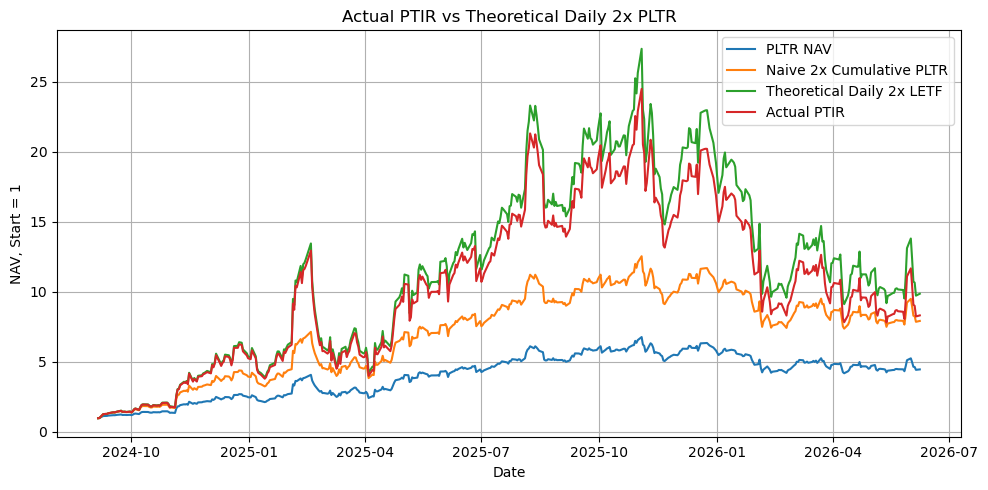

In [36]:
# ============================================================
# Plot: Actual LETF vs Theoretical 2x LETF vs Naive 2x Underlying
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    decay_df.index,
    decay_df["Underlying_NAV"],
    label=f"{selected_underlying} NAV"
)

plt.plot(
    decay_df.index,
    decay_df["Naive_2x_Underlying_NAV"],
    label=f"Naive {target_leverage:.0f}x Cumulative {selected_underlying}"
)

plt.plot(
    decay_df.index,
    decay_df["Theoretical_2x_LETF_NAV"],
    label=f"Theoretical Daily {target_leverage:.0f}x LETF"
)

plt.plot(
    decay_df.index,
    decay_df["Actual_LETF_NAV"],
    label=f"Actual {selected_letf}"
)

plt.title(f"Actual {selected_letf} vs Theoretical Daily {target_leverage:.0f}x {selected_underlying}")
plt.xlabel("Date")
plt.ylabel("NAV, Start = 1")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA8_{selected_letf}_actual_vs_theoretical_2x_nav.png",
    dpi=300
)

plt.show()

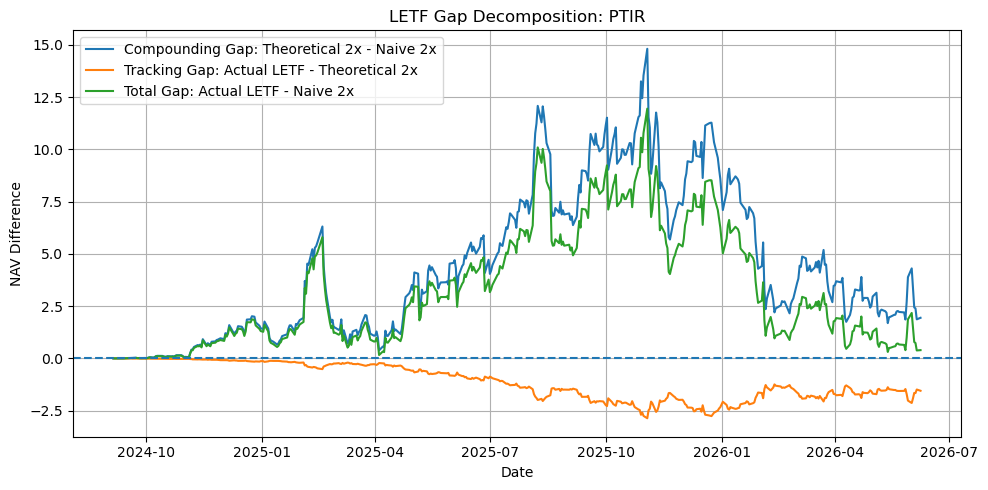

In [38]:
# ============================================================
# Plot: Gap Decomposition
# Purpose:
#   Show compounding gap, tracking gap, and total gap over time.
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    decay_df.index,
    decay_df["Compounding_Gap"],
    label="Compounding Gap: Theoretical 2x - Naive 2x"
)

plt.plot(
    decay_df.index,
    decay_df["Tracking_Gap"],
    label="Tracking Gap: Actual LETF - Theoretical 2x"
)

plt.plot(
    decay_df.index,
    decay_df["Total_Gap"],
    label="Total Gap: Actual LETF - Naive 2x"
)

plt.axhline(0, linestyle="--")

plt.title(f"LETF Gap Decomposition: {selected_letf}")
plt.xlabel("Date")
plt.ylabel("NAV Difference")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA9_{selected_letf}_gap_decomposition.png",
    dpi=300
)

plt.show()

# Save full decay analysis data
decay_df.to_csv(
    f"{data_path}/EDA_{selected_letf}_actual_vs_theoretical_decay_analysis.csv"
)

In [39]:
# ============================================================
# Summary Table: Actual vs Theoretical 2x LETF
# ============================================================

def nav_total_return(nav):
    return nav.iloc[-1] / nav.iloc[0] - 1

decay_summary = pd.DataFrame({
    "Series": [
        selected_underlying,
        f"Naive {target_leverage:.0f}x Cumulative {selected_underlying}",
        f"Theoretical Daily {target_leverage:.0f}x LETF",
        f"Actual {selected_letf}"
    ],
    "Ending NAV": [
        decay_df["Underlying_NAV"].iloc[-1],
        decay_df["Naive_2x_Underlying_NAV"].iloc[-1],
        decay_df["Theoretical_2x_LETF_NAV"].iloc[-1],
        decay_df["Actual_LETF_NAV"].iloc[-1]
    ],
    "Total Return": [
        nav_total_return(decay_df["Underlying_NAV"]),
        nav_total_return(decay_df["Naive_2x_Underlying_NAV"]),
        nav_total_return(decay_df["Theoretical_2x_LETF_NAV"]),
        nav_total_return(decay_df["Actual_LETF_NAV"])
    ],
    "Max Drawdown": [
        max_drawdown(decay_df["Underlying_NAV"]),
        max_drawdown(decay_df["Naive_2x_Underlying_NAV"]),
        max_drawdown(decay_df["Theoretical_2x_LETF_NAV"]),
        max_drawdown(decay_df["Actual_LETF_NAV"])
    ]
})

decay_summary_formatted = decay_summary.copy()

decay_summary_formatted["Ending NAV"] = decay_summary_formatted["Ending NAV"].apply(lambda x: f"{x:.4f}")
decay_summary_formatted["Total Return"] = decay_summary_formatted["Total Return"].apply(lambda x: f"{x:.2%}")
decay_summary_formatted["Max Drawdown"] = decay_summary_formatted["Max Drawdown"].apply(lambda x: f"{x:.2%}")

decay_summary_formatted.to_csv(
    f"{tables_path}/EDA7_{selected_letf}_actual_vs_theoretical_summary.csv",
    index=False
)

decay_summary_formatted

,Series,Ending NAV,Total Return,Max Drawdown
0,PLTR,4.4613,352.49%,-40.61%
1,Naive 2x Cumulative PLTR,7.9225,715.17%,-46.29%
2,Theoretical Daily 2x LETF,9.8662,915.16%,-68.63%
3,Actual PTIR,8.3184,752.43%,-69.10%


In [40]:
# ============================================================
# Summary Table: Actual vs Theoretical 2x LETF
# ============================================================

def nav_total_return(nav):
    return nav.iloc[-1] / nav.iloc[0] - 1

decay_summary = pd.DataFrame({
    "Series": [
        selected_underlying,
        f"Naive {target_leverage:.0f}x Cumulative {selected_underlying}",
        f"Theoretical Daily {target_leverage:.0f}x LETF",
        f"Actual {selected_letf}"
    ],
    "Ending NAV": [
        decay_df["Underlying_NAV"].iloc[-1],
        decay_df["Naive_2x_Underlying_NAV"].iloc[-1],
        decay_df["Theoretical_2x_LETF_NAV"].iloc[-1],
        decay_df["Actual_LETF_NAV"].iloc[-1]
    ],
    "Total Return": [
        nav_total_return(decay_df["Underlying_NAV"]),
        nav_total_return(decay_df["Naive_2x_Underlying_NAV"]),
        nav_total_return(decay_df["Theoretical_2x_LETF_NAV"]),
        nav_total_return(decay_df["Actual_LETF_NAV"])
    ],
    "Max Drawdown": [
        max_drawdown(decay_df["Underlying_NAV"]),
        max_drawdown(decay_df["Naive_2x_Underlying_NAV"]),
        max_drawdown(decay_df["Theoretical_2x_LETF_NAV"]),
        max_drawdown(decay_df["Actual_LETF_NAV"])
    ]
})

decay_summary_formatted = decay_summary.copy()

decay_summary_formatted["Ending NAV"] = decay_summary_formatted["Ending NAV"].apply(lambda x: f"{x:.4f}")
decay_summary_formatted["Total Return"] = decay_summary_formatted["Total Return"].apply(lambda x: f"{x:.2%}")
decay_summary_formatted["Max Drawdown"] = decay_summary_formatted["Max Drawdown"].apply(lambda x: f"{x:.2%}")

decay_summary_formatted.to_csv(
    f"{tables_path}/EDA7_{selected_letf}_actual_vs_theoretical_summary.csv",
    index=False
)

decay_summary_formatted

,Series,Ending NAV,Total Return,Max Drawdown
0,PLTR,4.4613,352.49%,-40.61%
1,Naive 2x Cumulative PLTR,7.9225,715.17%,-46.29%
2,Theoretical Daily 2x LETF,9.8662,915.16%,-68.63%
3,Actual PTIR,8.3184,752.43%,-69.10%


In [41]:
# ============================================================
# EDA Extension 6: Market Regime Analysis
# Purpose:
#   Classify the sample into simple regimes:
#   - Bull
#   - Bear
#   - Sideways / Choppy
#   - High Volatility
#   - Low Volatility
#
#   This connects the EDA to the project objective:
#   volatility decay under bull, bear, and sideways regimes.
# ============================================================

regime_df = decay_df.copy()

# Rolling indicators
regime_df["Underlying_20D_Vol"] = (
    regime_df["Underlying_Return"].rolling(20).std() * np.sqrt(252)
)

regime_df["Underlying_60D_Return"] = (
    regime_df["Underlying_Price"] / regime_df["Underlying_Price"].shift(60) - 1
)

# Use sample-based thresholds because PLTR/PTIR history is short
high_vol_threshold = regime_df["Underlying_20D_Vol"].quantile(0.70)
low_vol_threshold = regime_df["Underlying_20D_Vol"].quantile(0.30)

bull_threshold = regime_df["Underlying_60D_Return"].quantile(0.67)
bear_threshold = regime_df["Underlying_60D_Return"].quantile(0.33)

def classify_regime(row):
    """
    Classify regime using 60D trend and 20D volatility.
    """
    if pd.isna(row["Underlying_20D_Vol"]) or pd.isna(row["Underlying_60D_Return"]):
        return np.nan

    trend = row["Underlying_60D_Return"]
    vol = row["Underlying_20D_Vol"]

    if trend >= bull_threshold:
        return "Bull"
    elif trend <= bear_threshold:
        return "Bear"
    elif vol >= high_vol_threshold:
        return "Sideways / High Vol"
    else:
        return "Sideways / Low-Mid Vol"

regime_df["Regime"] = regime_df.apply(classify_regime, axis=1)

regime_df["Vol_Regime"] = np.where(
    regime_df["Underlying_20D_Vol"] >= high_vol_threshold,
    "High Vol",
    np.where(
        regime_df["Underlying_20D_Vol"] <= low_vol_threshold,
        "Low Vol",
        "Mid Vol"
    )
)

regime_df[["Underlying_60D_Return", "Underlying_20D_Vol", "Regime", "Vol_Regime"]].tail()

,Underlying_60D_Return,Underlying_20D_Vol,Regime,Vol_Regime
Date,,,,
2026-06-02,-0.031751,0.610999,Bear,Mid Vol
2026-06-03,-0.090967,0.605204,Bear,Mid Vol
2026-06-04,-0.062459,0.601804,Bear,Mid Vol
2026-06-05,-0.106003,0.618687,Bear,Mid Vol
2026-06-08,-0.110945,0.618876,Bear,Mid Vol


In [42]:
# ============================================================
# Regime Summary Table
# ============================================================

def summarize_regime(group):
    """
    Summarize return, volatility, realized leverage, decay, and short risk by regime.
    """
    if len(group) < 5:
        return pd.Series({
            "Observations": len(group),
            "Underlying Total Return": np.nan,
            "LETF Total Return": np.nan,
            "Short LETF Total Return": np.nan,
            "Underlying Ann Vol": np.nan,
            "LETF Ann Vol": np.nan,
            "Avg Rolling Beta 20D": np.nan,
            "Avg Compounding Gap": np.nan,
            "Avg Tracking Gap": np.nan,
            "Worst Short 1D Return": np.nan
        })

    underlying_nav = (1 + group["Underlying_Return"]).cumprod()
    letf_nav = (1 + group["LETF_Return"]).cumprod()
    short_nav = (1 - group["LETF_Return"]).cumprod()

    return pd.Series({
        "Observations": len(group),
        "Underlying Total Return": underlying_nav.iloc[-1] - 1,
        "LETF Total Return": letf_nav.iloc[-1] - 1,
        "Short LETF Total Return": short_nav.iloc[-1] - 1,
        "Underlying Ann Vol": group["Underlying_Return"].std() * np.sqrt(252),
        "LETF Ann Vol": group["LETF_Return"].std() * np.sqrt(252),
        "Avg Rolling Beta 20D": group["Rolling_Beta_20D"].mean(),
        "Avg Compounding Gap": group["Compounding_Gap"].mean(),
        "Avg Tracking Gap": group["Tracking_Gap"].mean(),
        "Worst Short 1D Return": (-group["LETF_Return"]).min()
    })

regime_summary = (
    regime_df
    .dropna(subset=["Regime"])
    .groupby("Regime")
    .apply(summarize_regime)
    .reset_index()
)

# Format for display
regime_summary_formatted = regime_summary.copy()

percent_cols = [
    "Underlying Total Return",
    "LETF Total Return",
    "Short LETF Total Return",
    "Underlying Ann Vol",
    "LETF Ann Vol",
    "Avg Compounding Gap",
    "Avg Tracking Gap",
    "Worst Short 1D Return"
]

for col in percent_cols:
    regime_summary_formatted[col] = regime_summary_formatted[col].apply(
        lambda x: "" if pd.isna(x) else f"{x:.2%}"
    )

regime_summary_formatted["Avg Rolling Beta 20D"] = regime_summary_formatted["Avg Rolling Beta 20D"].apply(
    lambda x: "" if pd.isna(x) else f"{x:.2f}"
)

regime_summary_formatted.to_csv(
    f"{tables_path}/EDA8_{selected_letf}_regime_summary.csv",
    index=False
)

regime_summary_formatted

/var/folders/77/jg5wr20n7yxgfjvvm_63s_xc0000gn/T/ipykernel_4173/2703856321.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_regime)


,Regime,Observations,Underlying Total Return,LETF Total Return,Short LETF Total Return,Underlying Ann Vol,LETF Ann Vol,Avg Rolling Beta 20D,Avg Compounding Gap,Avg Tracking Gap,Worst Short 1D Return
0,Bear,126.0,-50.93%,-81.05%,163.43%,58.37%,116.54%,1.99,454.13%,-174.23%,-18.46%
1,Bull,126.0,160.80%,410.18%,-93.34%,71.18%,141.80%,2.00,417.52%,-68.70%,-47.24%
2,Sideways / High Vol,50.0,5.91%,-2.93%,-37.33%,79.39%,158.71%,2.00,224.32%,-48.95%,-16.59%
3,Sideways / Low-Mid Vol,78.0,52.43%,113.61%,-62.64%,42.03%,83.71%,1.99,907.50%,-203.36%,-17.41%


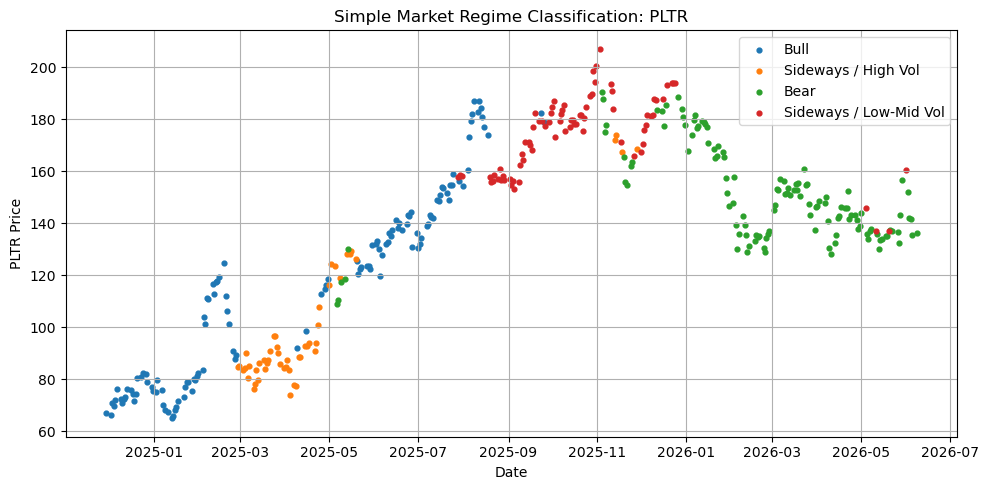

In [44]:
# ============================================================
# Plot: Regime Classification on Underlying Price
# ============================================================

plt.figure(figsize=(10, 5))

for regime_name in regime_df["Regime"].dropna().unique():
    temp = regime_df[regime_df["Regime"] == regime_name]
    plt.scatter(
        temp.index,
        temp["Underlying_Price"],
        s=12,
        label=regime_name
    )

plt.title(f"Simple Market Regime Classification: {selected_underlying}")
plt.xlabel("Date")
plt.ylabel(f"{selected_underlying} Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA10_{selected_underlying}_regime_classification.png",
    dpi=300
)

plt.show()

In [46]:
# ============================================================
# EDA Extension 7: Short Borrow Cost Sensitivity
# Purpose:
#   Show how sensitive the unhedged short LETF baseline is to borrow cost.
#
#   This is not yet the option hedge backtest.
#   It is a realism check for the short-only baseline.
# ============================================================

borrow_cost_scenarios = [0.00, 0.05, 0.10, 0.20, 0.30]  # annualized borrow cost assumptions

borrow_results = []

for annual_borrow_cost in borrow_cost_scenarios:
    daily_borrow_cost = annual_borrow_cost / 252

    # Short LETF daily return before borrow cost: -LETF return
    # Net return deducts daily borrow cost
    short_net_return = -eda_df["LETF_Return"] - daily_borrow_cost
    short_net_nav = (1 + short_net_return).cumprod()

    metrics = calculate_strategy_metrics(short_net_return)
    metrics["Annual Borrow Cost Assumption"] = annual_borrow_cost
    metrics["Ending NAV"] = short_net_nav.iloc[-1]

    borrow_results.append(metrics)

borrow_sensitivity = pd.DataFrame(borrow_results)

# Reorder columns
borrow_sensitivity = borrow_sensitivity[
    [
        "Annual Borrow Cost Assumption",
        "Ending NAV",
        "Total Return",
        "Annualized Return",
        "Annualized Vol",
        "Sharpe",
        "Max Drawdown",
        "Worst 1D Loss",
        "Best 1D Gain"
    ]
]

borrow_sensitivity_formatted = borrow_sensitivity.copy()

for col in [
    "Annual Borrow Cost Assumption",
    "Total Return",
    "Annualized Return",
    "Annualized Vol",
    "Max Drawdown",
    "Worst 1D Loss",
    "Best 1D Gain"
]:
    borrow_sensitivity_formatted[col] = borrow_sensitivity_formatted[col].apply(lambda x: f"{x:.2%}")

borrow_sensitivity_formatted["Ending NAV"] = borrow_sensitivity_formatted["Ending NAV"].apply(lambda x: f"{x:.4f}")
borrow_sensitivity_formatted["Sharpe"] = borrow_sensitivity_formatted["Sharpe"].apply(lambda x: f"{x:.2f}")

borrow_sensitivity_formatted.to_csv(
    f"{tables_path}/EDA9_{selected_letf}_short_borrow_cost_sensitivity.csv",
    index=False
)

borrow_sensitivity_formatted

,Annual Borrow Cost Assumption,Ending NAV,Total Return,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Worst 1D Loss,Best 1D Gain
0,0.00%,0.0058,-99.42%,-86.92%,129.33%,-0.67,-99.61%,-47.24%,24.56%
1,5.00%,0.0053,-99.47%,-87.56%,129.33%,-0.68,-99.63%,-47.26%,24.54%
2,10.00%,0.0048,-99.52%,-88.17%,129.33%,-0.68,-99.65%,-47.28%,24.52%
3,20.00%,0.0040,-99.60%,-89.31%,129.33%,-0.69,-99.71%,-47.32%,24.48%
4,30.00%,0.0034,-99.66%,-90.33%,129.33%,-0.70,-99.75%,-47.36%,24.44%


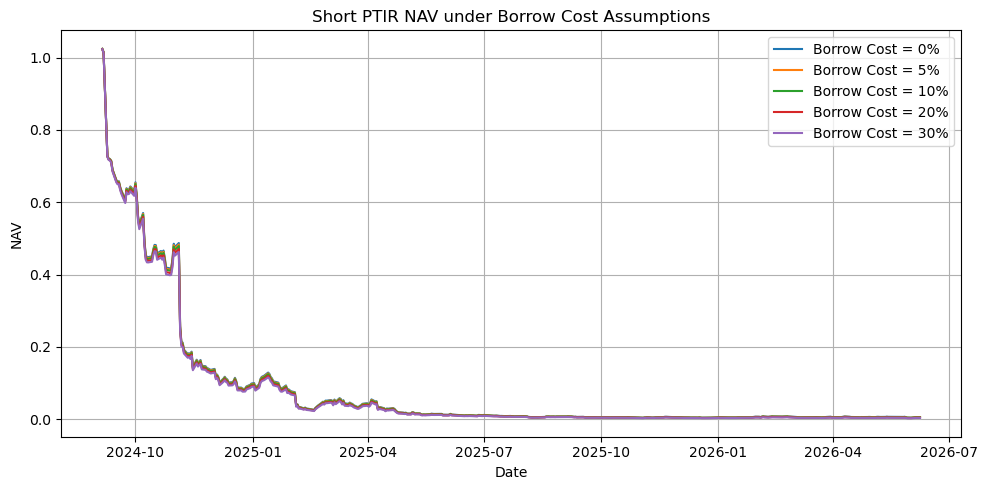

In [48]:
# ============================================================
# Plot: Short-only NAV under Borrow Cost Assumptions
# ============================================================

plt.figure(figsize=(10, 5))

for annual_borrow_cost in borrow_cost_scenarios:
    daily_borrow_cost = annual_borrow_cost / 252
    short_net_return = -eda_df["LETF_Return"] - daily_borrow_cost
    short_net_nav = (1 + short_net_return).cumprod()

    plt.plot(
        short_net_nav.index,
        short_net_nav,
        label=f"Borrow Cost = {annual_borrow_cost:.0%}"
    )

plt.title(f"Short {selected_letf} NAV under Borrow Cost Assumptions")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{figures_path}/EDA11_{selected_letf}_short_borrow_cost_sensitivity_nav.png",
    dpi=300
)

plt.show()